# I will now be building the midsize basic operations from the Clifford + T gate set

Allowed gates are Clifford gates: H, S, X, Y, Z, I, CNOT and all of their inverses  (add to this list any other Clifford gate I need, this isn't meant to be exhaustive)

and the only non-Clifford gate allowed is T

In [2]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector
import numpy as np
from matplotlib import pyplot as plt

from Elementary_circuits import subarithmetic_circuits
from Elementary_circuits import basic_arithmetic_circuits
from Elementary_circuits import midsize_basic_circuits

np.set_printoptions(legacy='1.25') # prevent the type beign printed in numpy output

# Arbitrary One-Qubit Gate

Test the Solovay-Kitaev approximation of an arbitrary one-qubit unitary to precision $\epsilon$ using only Clifford+T gates.

Performs the operation $\ket{\psi} \rightarrow U \ket{\psi}$ with $U = \begin{bmatrix}  e^{\alpha i} cos(\theta) &  -e^{\beta i} sin(\theta) \\ e^{-\beta i} sin(\theta) & e^{-\alpha i} cos(\theta)\end{bmatrix}$

In [3]:
epsilon = 0.1
theta = 0.37 # rotation angle, 0 <= theta <= 2*pi
alpha = 1.4 # phase angle, 0 <= alpha <= 2*pi
beta = 2.1 # phase angle, 0 <= beta <= 2*pi
'''target_matrix = np.array([
    [np.cos(theta/2), -np.sin(theta/2)],
    [np.sin(theta/2), np.cos(theta/2)]
], dtype=complex)'''
target_matrix = np.array([
    [np.exp(1j*alpha)*np.cos(theta), -np.exp(1j*beta)*np.sin(theta)],
    [np.exp(-1j*beta)*np.sin(theta), np.exp(-1j*alpha)*np.cos(theta)]
], dtype=complex)

x = QuantumRegister(1, 'x') # one qubit register
qc = QuantumCircuit(x)
midsize_basic_circuits.arbitrary_single_qubit_gate(
    qc, target_matrix, x, epsilon
)

# Compare the synthesized operator with the target up to global phase.
approximate_matrix = Operator(qc).data
phase = np.angle(np.vdot(approximate_matrix, target_matrix))
error = np.linalg.norm(
    target_matrix - np.exp(1j*phase)*approximate_matrix, ord=2
)
unexpected_gates = set(qc.count_ops()) - {'h', 't', 'tdg'}

print("Target matrix: ", target_matrix)
print("Approximate matrix: ", approximate_matrix)

allTestsPassed = error <= epsilon and not unexpected_gates
if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
    print("operator error: ", error)
    print("unexpected gates: ", unexpected_gates)
print(dict(qc.count_ops()))
#qc.draw('mpl') # draw the circuit, but it may be too large to display

Target matrix:  [[ 0.15846502+0.91876173j  0.18256014-0.31214983j]
 [-0.18256014-0.31214983j  0.15846502-0.91876173j]]
Approximate matrix:  [[ 0.1767767+0.9267767j   0.1767767-0.28033009j]
 [-0.1767767-0.28033009j  0.1767767-0.9267767j ]]
All tests passed.
{'h': 14, 't': 11, 'tdg': 9}


# Arbitrary N-Qubit Gate

Test the Quantum Shannon and Solovay-Kitaev approximation of an arbitrary two-qubit unitary to precision $\epsilon$ using only Clifford+T gates.

In [4]:
epsilon = 0.01
theta_1, alpha_1, beta_1 = 0.37, 1.4, 2.1
theta_2, alpha_2, beta_2 = 0.61, 0.8, 1.7

def one_qubit_unitary(theta, alpha, beta):
    return np.array([
        [np.exp(1j*alpha)*np.cos(theta), -np.exp(1j*beta)*np.sin(theta)],
        [np.exp(-1j*beta)*np.sin(theta), np.exp(-1j*alpha)*np.cos(theta)]
    ], dtype=complex)

u_1 = one_qubit_unitary(theta_1, alpha_1, beta_1)
u_2 = one_qubit_unitary(theta_2, alpha_2, beta_2)
cx_matrix = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
], dtype=complex)
target_matrix = cx_matrix @ np.kron(u_1, u_2)

x = QuantumRegister(2, 'x') # two-qubit register
qc = QuantumCircuit(x)
midsize_basic_circuits.arbitrary_n_qubit_gate(
    qc, target_matrix, x, epsilon
)

# Compare the synthesized operator with the target up to global phase.
approximate_matrix = Operator(qc).data
phase = np.angle(np.vdot(approximate_matrix, target_matrix))
error = np.linalg.norm(
    target_matrix - np.exp(1j*phase)*approximate_matrix, ord=2
)
unexpected_gates = set(qc.count_ops()) - {'h', 't', 'tdg', 'cx'}

print("Target matrix: ", target_matrix)
print("Approximate matrix: ", approximate_matrix)

allTestsPassed = error <= epsilon and not unexpected_gates
if allTestsPassed:
    print("All tests passed.")
else:
    print("One or more tests failed.")
    print("operator error: ", error)
    print("unexpected gates: ", unexpected_gates)
print(dict(qc.count_ops()))
#qc.draw('mpl') # draw the circuit, but it may be too large to display

Target matrix:  [[-0.44972094+0.61783699j  0.53363808-0.02220823j  0.28778945-0.07091287j
  -0.16385506-0.12675108j]
 [ 0.51024522-0.15783734j  0.63070519+0.43148863j -0.19080489-0.08067101j
  -0.07928595-0.28559611j]
 [-0.16385506+0.12675108j -0.28778945-0.07091287j -0.53363808-0.02220823j
  -0.44972094-0.61783699j]
 [ 0.07928595-0.28559611j -0.19080489+0.08067101j  0.63070519-0.43148863j
  -0.51024522-0.15783734j]]
Approximate matrix:  [[-0.45138991+0.61745988j  0.53294457-0.01999556j  0.28780076-0.07057933j
  -0.16297794-0.12723275j]
 [ 0.50865942-0.16062519j  0.63277318+0.42953818j -0.19070207-0.07923123j
  -0.08052639-0.28536088j]
 [-0.1633507 +0.12578435j -0.28805379-0.07127808j -0.53178713-0.02256125j
  -0.45000824-0.61937494j]
 [ 0.07969511-0.2856556j  -0.19023902+0.08011792j  0.63228702-0.43179969j
  -0.50828866-0.15762167j]]
All tests passed.
{'h': 5114, 't': 3094, 'tdg': 3085, 'cx': 1}


# Arbitrary 1-qubit gate Clifford and T gate Requirements
For the 2x2 matrix defined with the parameters $\theta = 0.37$, $\alpha = 1.4$, and $\beta = 2.1$, plot the number of Clifford and T gates required to apply this gate to precision $\epsilon$ with $\max_{\lvert \lvert \ket{\psi} \rvert \rvert = 1} \lvert \lvert U \ket{\psi} - U_{approx}(\phi) \ket{\psi} \rvert \rvert \leq \epsilon$

Recursion degree =  0  simulation complete
Approximation error: 0.12079030303600993
Gate counts: {'t': 4, 'h': 4, 'tdg': 2}
Recursion degree =  1  simulation complete
Approximation error: 0.03801975180450355
Gate counts: {'h': 14, 't': 11, 'tdg': 9}
Recursion degree =  2  simulation complete
Approximation error: 0.020606526394149127
Gate counts: {'h': 102, 't': 65, 'tdg': 63}
Recursion degree =  3  simulation complete
Approximation error: 0.004926428982594148
Gate counts: {'h': 414, 't': 248, 'tdg': 246}
Recursion degree =  4  simulation complete
Approximation error: 0.00036618001500189157
Gate counts: {'h': 2120, 't': 1305, 'tdg': 1303}
Recursion degree =  5  simulation complete
Approximation error: 1.3861382528248437e-05
Gate counts: {'h': 10750, 't': 6734, 'tdg': 6732}
Recursion degree =  6  simulation complete
Approximation error: 2.0844027370092703e-08
Gate counts: {'h': 49866, 't': 30928, 'tdg': 30926}
Recursion degree =  7  simulation complete
Approximation error: 2.084402737009

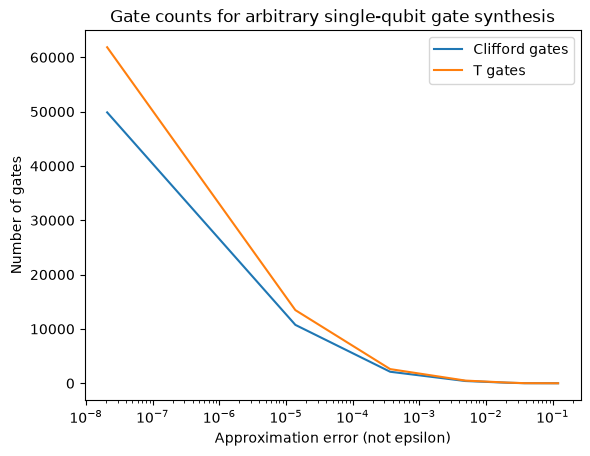

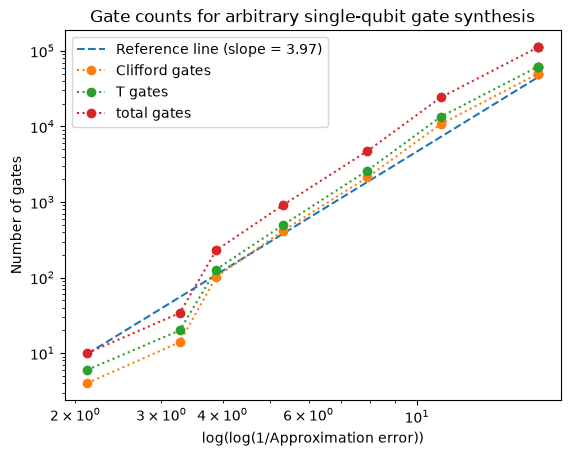

In [2]:
#epsilons = np.logspace(-5, -1, 20)
recursion_degrees = list(range(0, 9))
errors = []
clifford_gates = []
T_gates = []
for recursion_degree in recursion_degrees:
    theta = 0.37 # rotation angle, 0 <= theta <= 2*pi
    alpha = 1.4 # phase angle, 0 <= alpha <= 2*pi
    beta = 2.1 # phase angle, 0 <= beta <= 2*pi
    target_matrix = np.array([
        [np.exp(1j*alpha)*np.cos(theta), -np.exp(1j*beta)*np.sin(theta)],
        [np.exp(-1j*beta)*np.sin(theta), np.exp(-1j*alpha)*np.cos(theta)]
    ], dtype=complex)

    x = QuantumRegister(1, 'x') # one qubit register
    qc = QuantumCircuit(x)
    midsize_basic_circuits.arbitrary_single_qubit_gate(
        qc, target_matrix, x, recursion_degree=recursion_degree
    )

    # Compare the synthesized operator with the target up to global phase.
    approximate_matrix = Operator(qc).data
    phase = np.angle(np.vdot(approximate_matrix, target_matrix))
    error = np.linalg.norm(
        target_matrix - np.exp(1j*phase)*approximate_matrix, ord=2
    )

    print("Recursion degree = ", recursion_degree, " simulation complete")
    print("Approximation error:", error)
    print("Gate counts:", dict(qc.count_ops()))

    errors.append(error)
    clifford_gates.append(sum(qc.count_ops().get(gate, 0) for gate in ['h', 's', 'sdg']))
    T_gates.append(qc.count_ops().get('t', 0) + qc.count_ops().get('tdg', 0))

total_gates = [T + C for T, C in zip(T_gates, clifford_gates)]

print("Errors: ", errors)
print("T gates: ", T_gates)
print("Clifford gates: ", clifford_gates)
print("Total gates: ", total_gates)

plt.plot(errors, clifford_gates, label='Clifford gates')
plt.plot(errors, T_gates, label='T gates')
plt.xscale('log')
plt.xlabel('Approximation error (not epsilon)')
plt.ylabel('Number of gates')
plt.title('Gate counts for arbitrary single-qubit gate synthesis')
plt.legend()
plt.show()

# the total number of gates should scale with O(log^3.97(1/epsilon)) so we can plot the log of the number of gates against log^(1/error) and the slope should be approximately 3.97
logerrors = [np.log(1/error) for error in errors]

# reference line that has slope of 3.97
x_ref = np.linspace(min(logerrors), max(logerrors), 100)
y_ref = 0.5 * x_ref**3.97
plt.plot(x_ref, y_ref, '--', label='Reference line (slope = 3.97)')

plt.plot(logerrors, clifford_gates, ':o', label='Clifford gates')
plt.plot(logerrors, T_gates, ':o', label='T gates')
plt.plot(logerrors, total_gates, ':o', label='total gates')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('log(log(1/Approximation error))')
plt.ylabel('Number of gates')
plt.title('Gate counts for arbitrary single-qubit gate synthesis')
plt.legend()
plt.show()

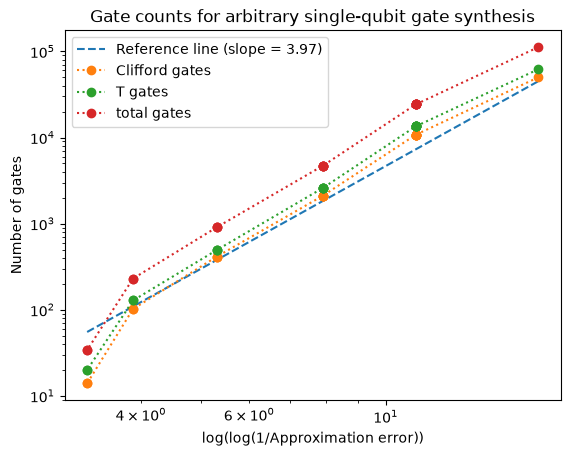

In [9]:
errors = [2.0844027370092703e-08, 1.3861382528248437e-05, 1.3861382528248437e-05, 1.3861382528248437e-05, 1.3861382528248437e-05, 1.3861382528248437e-05, 1.3861382528248437e-05, 1.3861382528248437e-05, 0.00036618001500189157, 0.00036618001500189157, 0.00036618001500189157, 0.00036618001500189157, 0.00036618001500189157, 0.004926428982594148, 0.004926428982594148, 0.004926428982594148, 0.020606526394149127, 0.020606526394149127, 0.03801975180450355, 0.03801975180450355]
T_gates = [61854, 13466, 13466, 13466, 13466, 13466, 13466, 13466, 2608, 2608, 2608, 2608, 2608, 494, 494, 494, 128, 128, 20, 20]
Clifford_gates = [49866, 10750, 10750, 10750, 10750, 10750, 10750, 10750, 2120, 2120, 2120, 2120, 2120, 414, 414, 414, 102, 102, 14, 14]
total_gates = [T + C for T, C in zip(T_gates, Clifford_gates)]

# the total number of gates should scale with O(log^3.97(1/epsilon)) so we can plot the log of the number of gates against log^(1/error) and the slope should be approximately 3.97
logerrors = [np.log(1/error) for error in errors]

# reference line that has slope of 3.97
x_ref = np.linspace(min(logerrors), max(logerrors), 100)
y_ref = 0.5 * x_ref**3.97
plt.plot(x_ref, y_ref, '--', label='Reference line (slope = 3.97)')

plt.plot(logerrors, clifford_gates, ':o', label='Clifford gates')
plt.plot(logerrors, T_gates, ':o', label='T gates')
plt.plot(logerrors, total_gates, ':o', label='total gates')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('log(log(1/Approximation error))')
plt.ylabel('Number of gates')
plt.title('Gate counts for arbitrary single-qubit gate synthesis')
plt.legend()
plt.show()

# Arbitrary multi-qubit gate Clifford and T gate requirements

For the 4x4 (two-qubit) unitary below, apply Quantum Shannon decomposition followed by Solovay-Kitaev synthesis at several recursion degrees. Plot the Clifford and T gate requirements as a function of the achieved operator-norm error $\epsilon$, computed up to global phase.

recursion_degree=0, error=2.990e-01, gates={'t': 14, 'h': 8, 'tdg': 5, 'cx': 1}
recursion_degree=1, error=1.539e-01, gates={'h': 72, 't': 51, 'tdg': 42, 'cx': 1}
recursion_degree=2, error=4.801e-02, gates={'h': 352, 't': 227, 'tdg': 218, 'cx': 1}
recursion_degree=3, error=1.246e-02, gates={'h': 1530, 't': 936, 'tdg': 927, 'cx': 1}
recursion_degree=4, error=1.437e-03, gates={'h': 8382, 't': 5087, 'tdg': 5078, 'cx': 1}
recursion_degree=5, error=4.143e-05, gates={'h': 41800, 't': 25582, 'tdg': 25573, 'cx': 1}


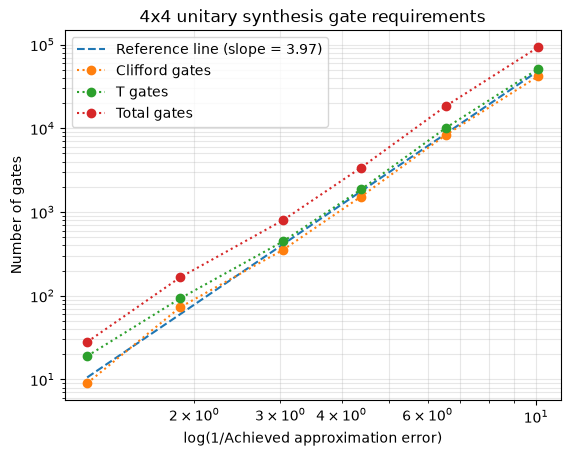

In [9]:
# A reproducible entangling 4x4 unitary.
def one_qubit_unitary(theta, alpha, beta):
    return np.array([
        [np.exp(1j * alpha) * np.cos(theta),
         -np.exp(1j * beta) * np.sin(theta)],
        [np.exp(-1j * beta) * np.sin(theta),
         np.exp(-1j * alpha) * np.cos(theta)]
    ], dtype=complex)

u_1 = one_qubit_unitary(0.37, 1.4, 2.1)
u_2 = one_qubit_unitary(0.61, 0.8, 1.7)
cx_matrix = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
], dtype=complex)
target_matrix_4x4 = cx_matrix @ np.kron(u_1, u_2)

recursion_degrees_4x4 = list(range(6))
errors_4x4 = []
clifford_gates_4x4 = []
T_gates_4x4 = []
clifford_gate_names = {'h', 's', 'sdg', 'x', 'y', 'z', 'id', 'cx'}
allowed_gate_names = clifford_gate_names | {'t', 'tdg'}

for recursion_degree in recursion_degrees_4x4:
    x = QuantumRegister(2, 'x')
    qc = QuantumCircuit(x)
    midsize_basic_circuits.arbitrary_n_qubit_gate(
        qc, target_matrix_4x4, x,
        recursion_degree=recursion_degree,
    )

    approximate_matrix = Operator(qc).data
    phase = np.angle(np.vdot(approximate_matrix, target_matrix_4x4))
    error = np.linalg.norm(
        target_matrix_4x4
        - np.exp(1j * phase) * approximate_matrix,
        ord=2,
    )
    gate_counts = qc.count_ops()
    unexpected_gates = set(gate_counts) - allowed_gate_names
    if unexpected_gates:
        raise AssertionError(f'Unexpected gates: {unexpected_gates}')
    errors_4x4.append(error)
    clifford_gates_4x4.append(sum(
        gate_counts.get(gate, 0) for gate in clifford_gate_names
    ))
    T_gates_4x4.append(
        gate_counts.get('t', 0) + gate_counts.get('tdg', 0)
    )
    print(
        f'recursion_degree={recursion_degree}, error={error:.3e}, '
        f'gates={dict(gate_counts)}'
    )

logerrors_4x4 = [np.log(1/error) for error in errors_4x4]
total_gates_4x4 = np.add(clifford_gates_4x4, T_gates_4x4)

# reference line that has slope of 3.97
x_ref = np.linspace(min(logerrors_4x4), max(logerrors_4x4), 100)
y_ref = 5 * x_ref**3.97
plt.plot(x_ref, y_ref, '--', label='Reference line (slope = 3.97)')

plt.loglog(logerrors_4x4, clifford_gates_4x4, ':o', label='Clifford gates')
plt.loglog(logerrors_4x4, T_gates_4x4, ':o', label='T gates')
plt.loglog(logerrors_4x4, total_gates_4x4, ':o', label='Total gates')
plt.xlabel(r'log(1/Achieved approximation error)')
plt.ylabel('Number of gates')
plt.title('4x4 unitary synthesis gate requirements')
plt.grid(True, which='both', alpha=0.3)
plt.legend()

plt.show()